Comparing Model XGB, Logistic Regression, Random Forrest

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))


In [2]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

from src.preprocessing import AmountTimeScaler, split_X_y
from src.utils import metrics_at_threshold, threshold_for_target_recall, summarize

DATA_PROCESSED = Path("../data/processed")
train = pd.read_csv(DATA_PROCESSED / "batch1_train.csv")
test  = pd.read_csv(DATA_PROCESSED / "batch2_test.csv")
stream1 = pd.read_csv(DATA_PROCESSED / "batch3_stream.csv")
stream2 = pd.read_csv(DATA_PROCESSED / "batch4_stream.csv")


In [3]:
X_train_full, y_train_full = split_X_y(train)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42
)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RF": RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced_subsample",
    ),
}

if HAS_XGB:
    models["XGB"] = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42,
        # you can also try: scale_pos_weight = (num_neg / num_pos)
    )
else:
    # fallback so we still have 3 models
    models["GB"] = GradientBoostingClassifier(random_state=42)


In [8]:
TARGET_RECALL = 0.80
results = {}

def fit_and_threshold(name, clf):
    pipe = Pipeline([
        ("scaler", AmountTimeScaler(scale_time=True)),
        ("clf", clf),
    ])
    pipe.fit(X_tr, y_tr)
    val_scores = pipe.predict_proba(X_val)[:,1]
    thr = threshold_for_target_recall(y_val, val_scores, TARGET_RECALL)
    results[name] = {"pipe": pipe, "thr": thr}

for name, clf in models.items():
    fit_and_threshold(name, clf)

{k: v["thr"] for k, v in results.items()}


{'LogReg': 0.00105131323229303, 'RF': 0.0025, 'XGB': 0.001003154437057674}

In [9]:
def evaluate_on_batches(pipe, thr):
    table = []
    for label, df in [("TEST", test), ("STREAM1", stream1), ("STREAM2", stream2)]:
        X, y = split_X_y(df)
        scores = pipe.predict_proba(X)[:,1]
        table.append(summarize(y, scores, thr).assign(batch=label))
    out = pd.concat(table, ignore_index=True)
    return out[["batch","threshold","precision","recall","f1","pr_auc","TP","FP","TN","FN","flagged","flagged_pct"]]

all_model_tables = {name: evaluate_on_batches(v["pipe"], v["thr"]) for name, v in results.items()}
for name, df in all_model_tables.items():
    print(name)
    display(df)


LogReg


,batch,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct
0,TEST,0.001051,0.216374,0.787234,0.339450,0.368661,37,134,9819,10,171,0.0171
1,STREAM1,0.001051,0.072289,0.666667,0.130435,0.347861,6,77,9914,3,83,0.0083
2,STREAM2,0.001051,0.133333,1.000000,0.235294,0.662630,10,65,9925,0,75,0.0075


RF


,batch,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct
0,TEST,0.0025,0.064140,0.936170,0.120055,0.390946,44,642,9311,3,686,0.0686
1,STREAM1,0.0025,0.009050,0.666667,0.017857,0.666967,6,657,9334,3,663,0.0663
2,STREAM2,0.0025,0.013495,1.000000,0.026631,0.911364,10,731,9259,0,741,0.0741


XGB


,batch,threshold,precision,recall,f1,pr_auc,TP,FP,TN,FN,flagged,flagged_pct
0,TEST,0.001003,0.126844,0.914894,0.222798,0.392308,43,296,9657,4,339,0.0339
1,STREAM1,0.001003,0.031532,0.777778,0.060606,0.540520,7,215,9776,2,222,0.0222
2,STREAM2,0.001003,0.039062,1.000000,0.075188,0.929412,10,246,9744,0,256,0.0256


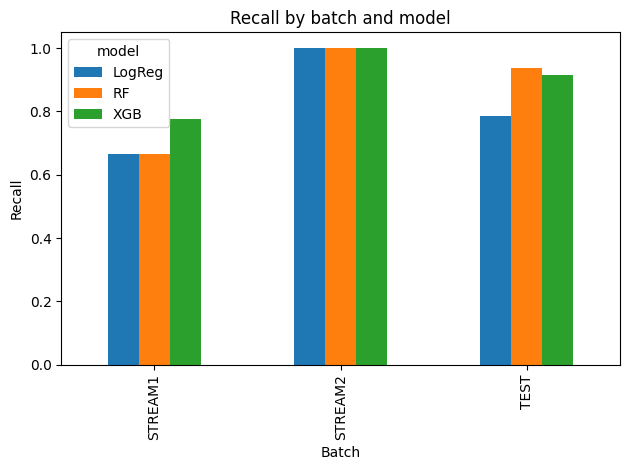

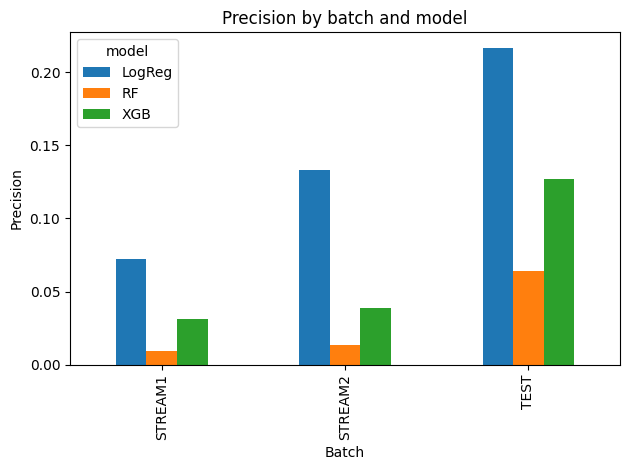

In [10]:
import matplotlib.pyplot as plt

# combine all into one df
df_all = []
for name, df in all_model_tables.items():
    df_all.append(df.assign(model=name))
df_all = pd.concat(df_all, ignore_index=True)

# plot recall per batch per model
for metric in ["recall", "precision"]:
    pivoted = df_all.pivot(index="batch", columns="model", values=metric)
    ax = pivoted.plot(kind="bar")
    ax.set_title(f"{metric.capitalize()} by batch and model")
    ax.set_ylabel(metric.capitalize())
    ax.set_xlabel("Batch")
    plt.tight_layout()
    plt.show()


In [25]:
from inspect import getsource
from src import utils
print(getsource(utils.threshold_for_target_recall))


def threshold_for_target_recall(y_true, y_score, target_recall=0.8, min_thr=1e-3, max_flagged=0.2):
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    # Compute fraction flagged for each candidate threshold
    flagged_frac = [(y_score >= t).mean() for t in thr]
    best_thr = 0.5
    for r, f, t in zip(rec[1:], flagged_frac, thr):
        if r >= target_recall and f <= max_flagged and t >= min_thr:
            best_thr = float(t)
            break
    return best_thr

